# Titanic predicción con Random Forest

- author: Virginia Ordoño Bernier
- date: April 2024

Intenta aplicar lo aprendido con las lecciones de ingeniería de propiedades con el conjunto de datos de Titanic disponible en Kaggle. Este dataset es accesible y contiene una mezcla de tipos de datos categóricos y numéricos, lo que lo hace perfecto para ejercitar diversas técnicas de ingeniería de propiedades. La tarea consiste en predecir la supervivencia de los pasajeros del Titanic utilizando machine learning.

Tareas Específicas:

1. Análisis Exploratorio de Datos (EDA): Buscar valores faltantes e identifica las posibles relaciones entre las características y la variable objetivo.

2. Limpieza de Datos: Basándose en el EDA debes tratar los valores faltantes y corregir posibles errores en los datos

3. Construye un modelo base para poder comparar sus resultados con otros después de aplicar ingeniería de propiedades.

4.  Elimina las características irrelevantes y prueba el modelo, si no hay mejora no las quites. 

5. Aplicar técnicas de ingeniería de propiedades para transformar y crear nuevas características. Algunas sugerencias:

- Crea una característica de "Tamaño de la familia" sumando las características SibSp (número de hermanos/cónyuges a bordo) y Parch (número de padres/hijos a bordo).
- Extrae el título de la característica Name y usarlo para crear una nueva característica que pueda indicar el estatus social o el género, lo que podría influir en la supervivencia.
- Crea bandas de edad para transformar la edad en una característica categórica, facilitando la captura de relaciones no lineales con la supervivencia.
- Aplica target encoding a la característica Cabin considerando la letra de la cabina como una indicación de la cubierta, lo que podría afectar las posibilidades de supervivencia.

Prueba con random forest.

## 1. Carga de datos

In [688]:
import pandas as pd # type: ignore
import numpy as np # type: ignore

# Ajuste de los datos ya que los archivos originales vienen separados
trd = pd.read_csv('./data/train.csv')
tsd = pd.read_csv('./data/test.csv')
gender_submission = pd.read_csv('./data/gender_submission.csv')

# Combina los datos de entrenamiento y prueba en un solo DataFrame
df = pd.concat([trd, tsd], ignore_index=True, sort=False)

# Fusiona gender_submission en df usando PassengerId como clave de unión
df_merged = pd.merge(df, gender_submission, on='PassengerId', how='left')

# Define una función para reemplazar NaN en 'Survived'
def get_survived(row):
    if pd.isna(row['Survived']):
        passenger_id = row['PassengerId']
        survived_value = gender_submission.loc[gender_submission['PassengerId'] == passenger_id, 'Survived'].values[0]
        return survived_value
    else:
        return row['Survived']

# Aplica la función a la columna 'Survived' de df
df['Survived'] = df.apply(get_survived, axis=1)

# Verifica los primeros registros para confirmar la sustitución
df.columns = df.columns.str.lower()

# Elimina la columna del id porque no aporta información relevante
df.drop(['passengerid'], axis=1, inplace=True)

# Convertimos survived columna a entero
df['survived'] = df['survived'].astype('int64')

df.head().T


,0,1,2,3,4
survived,0,1,1,1,0
pclass,3,1,3,1,3
name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th...","Heikkinen, Miss. Laina","Futrelle, Mrs. Jacques Heath (Lily May Peel)","Allen, Mr. William Henry"
sex,male,female,female,female,male
age,22.0,38.0,26.0,35.0,35.0
sibsp,1,1,0,1,0
parch,0,0,0,0,0
ticket,A/5 21171,PC 17599,STON/O2. 3101282,113803,373450
fare,7.25,71.2833,7.925,53.1,8.05
cabin,NaN,C85,NaN,C123,NaN


## 2. Exploración de datos

In [689]:
df.shape

(1309, 11)

In [690]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  1309 non-null   int64  
 1   pclass    1309 non-null   int64  
 2   name      1309 non-null   object 
 3   sex       1309 non-null   object 
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   ticket    1309 non-null   object 
 8   fare      1308 non-null   float64
 9   cabin     295 non-null    object 
 10  embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


### Explicación de las columnas

- PassengerId: identificación personal. Se elimina porque no aporta información relevante.
- Survived: variable objetivo. Era float. Se convierte a entero (0, 1)
- Pclass (Clase de Pasajero) es el nivel socioeconómico del pasajero y es una característica categórica ordinal que tiene 3 valores únicos:
1 = Clase Alta
2 = Clase Media
3 = Clase Baja
- Nombre, Sexo y Edad son autoexplicativos.
- SibSp: es el número total de hermanos y cónyuges del pasajero.
- Parch: número total de padres e hijos del pasajero.
- Ticket: número del billete del pasajero.
- Fare:  tarifa del pasajero.
- Cabin: identificación de camarote del pasajero.
- Embarked: puerto de embarque y es una característica categórica que tiene 3 valores únicos (C, Q o S):
C = Cherbourg
Q = Queenstown
S = Southampton

### Balanceo de clases

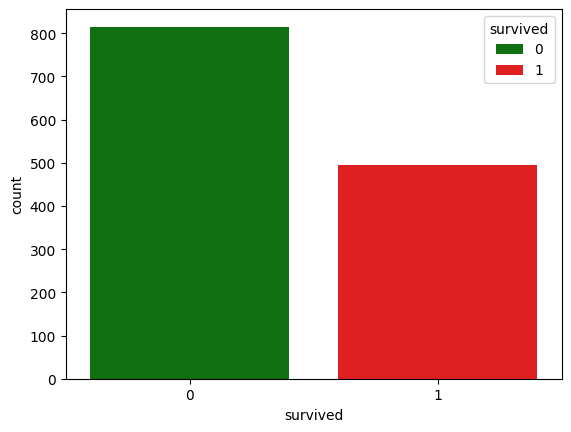

Porcentaje de desequilibrio: 37.74%


In [691]:
from matplotlib import pyplot as plt
import seaborn as sns

# Desbalanceo entre 20% y 40% es leve, por lo que se deja como está.
# Calcular el porcentaje de desequilibrio
canceled_counts = df['survived'].value_counts()
total_samples = canceled_counts.sum()
imbalance_percentage = (canceled_counts[1] / total_samples) * 100
sns.countplot(data=df, x=df['survived'], hue='survived', palette=['green', 'red'])
plt.show()
print(f'Porcentaje de desequilibrio: {imbalance_percentage:.2f}%')

### Detección de duplicados

In [692]:
if df.duplicated().any():
    duplicated_rows = df[df.duplicated(keep=False)]  # keep=False para marcar todas las filas duplicadas
    print(duplicated_rows)

### Detección de NaN

In [693]:
# Rows = 1309
if (df.isna().sum() > 0).any():
    print(df.isna().sum()[df.isna().sum() > 0])

age          263
fare           1
cabin       1014
embarked       2
dtype: int64


### Gestión de NaN

In [694]:
# Embarked: Rellenamos con la moda
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Fare: Rellenamos con la media. MIRAR EL PUERTO TAMBIÉN PARA ASIGNAR LA MEDIA y el PClass
df['fare'] = df['fare'].fillna(df['fare'].mean())

# Cabin: Rellenamos con 'unknown'
df['cabin'] = df['cabin'].fillna('unknown')

# Edad media de hombres y mujeres y y asignación de valores nulos
age_by_sex = df.groupby('sex')['age'].mean()

# Imputar valores nulos en 'Age' con la media de la edad por sexo. Podríamos considerar también los que tienen hijos.
df['age'] = df.apply(lambda row: age_by_sex[row['sex']] if pd.isnull(row['age']) else row['age'], axis=1)


In [695]:
# Comprobamos que ya no hay NaN
if (df.isna().sum() > 0).any():
    print(df.isna().sum()[df.isna().sum() > 0])

## 3. Modelo Base

In [696]:
df_base = df.copy()

### Detección de columnas categóricas

In [697]:
categorical_features = df_base.select_dtypes(include=['object']).columns.tolist()

print(f"Propiedades categóricas: {categorical_features}")


Propiedades categóricas: ['name', 'sex', 'ticket', 'cabin', 'embarked']


### One hot encoding

In [698]:
df_base = pd.get_dummies(df_base, columns=categorical_features)

df_base.columns


Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare',
       'name_Abbing, Mr. Anthony', 'name_Abbott, Master. Eugene Joseph',
       'name_Abbott, Mr. Rossmore Edward',
       'name_Abbott, Mrs. Stanton (Rosa Hunt)',
       ...
       'cabin_F2', 'cabin_F33', 'cabin_F38', 'cabin_F4', 'cabin_G6', 'cabin_T',
       'cabin_unknown', 'embarked_C', 'embarked_Q', 'embarked_S'],
      dtype='object', length=2434)

### Método que devuelve la precisión del modelo

In [699]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split

def get_random_forest_classifier(df, target):

    X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_score = scores.mean()

    return mean_score, y_pred, y_test, model

### Construcción Modelo Base

In [700]:
# Precisión 0.87

target_base = df_base.pop('survived')

score, y_pred, y_test, model = get_random_forest_classifier(df_base, target_base)
print(f'Precision modelo base: {score:.2f}')

Precision modelo base: 0.87


### Escalamiento de los datos

In [701]:
from sklearn.preprocessing import StandardScaler

# Precisión 0.87. Igual que sin escalamiento

scaler = StandardScaler()

# Seleccionar todas las características numéricas para escalar
numeric_features = df_base.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Escalar las características seleccionadas
df_base[numeric_features] = scaler.fit_transform(df_base[numeric_features])

score, y_pred, y_test, model = get_random_forest_classifier(df_base, target_base)
print(f'Precision modelo base con datos escalados: {score:.2f}')


Precision modelo base con datos escalados: 0.87


### Matriz de confusión

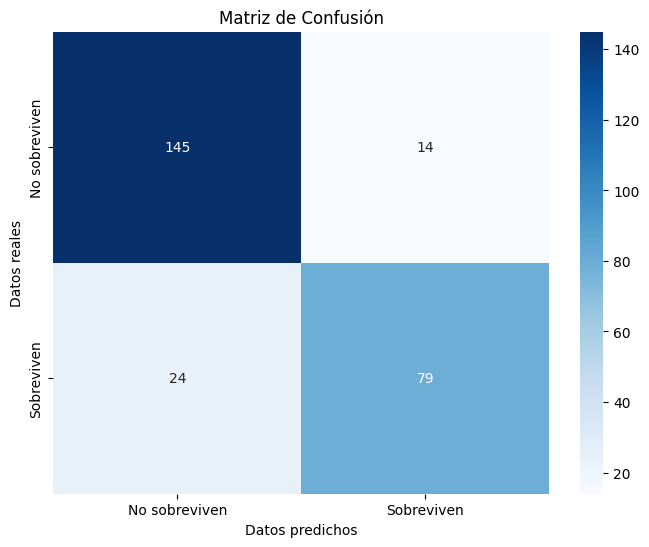

In [702]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_labels=None, figsize=(8, 6)):
    # Calcular la matriz de confusión
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Definir etiquetas de clase si no se proporcionan
    if class_labels is None:
        class_labels = ['Class {}'.format(i) for i in range(conf_matrix.shape[0])]
    
    # Crear un heatmap de la matriz de confusión
    plt.figure(figsize=figsize)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    
    # Añadir etiquetas y título
    plt.xlabel('Datos predichos')
    plt.ylabel('Datos reales')
    plt.title('Matriz de Confusión')
    
    # Mostrar el gráfico
    plt.show()


plot_confusion_matrix(y_test, y_pred, class_labels=['No sobreviven', 'Sobreviven'])


## 4. Mutual information

### Preparación datos MI

In [703]:
from sklearn.feature_selection import mutual_info_classif #type: ignore

df_mut_inf = df.copy()

target_mut_inf = df_mut_inf.pop('survived')

# Convierte las columnas de tipo 'object' a enteros
# Devuelve dos valores: el DataFrame con las columnas convertidas y un diccionario con las correspondencias
# df_mut_inf contendrá códigos numéricos que representan los valores categóricos originales.
for colname in df_mut_inf.select_dtypes("object"):
    df_mut_inf[colname], _ = df_mut_inf[colname].factorize() 

# Serie booleana donde cada entrada indica si cada columna 
# es de tipo entero (int) (True) o no (False). En este caso todo False. 
discrete_features = df_mut_inf.dtypes == int

In [704]:
def make_mi_scores(X, y, discrete_features):
    '''
    Devuelve una serie con los valores de información mutua para cada columna de X respecto a y.
    '''
    
    # Calcula la información mutua entre cada columna de X y y
    # y devuelve un array con los valores de información mutua.
    # Discrete features es una serie booleana que indica si cada columna de X es de tipo entero (int) o no.
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    
    # Conversión de los valores de información mutua en una serie de pandas
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    
    mi_scores = mi_scores.sort_values(ascending=False)
    
    return mi_scores

### Resultado datos MI

In [705]:
mi_scores = make_mi_scores(df_mut_inf, target_mut_inf, discrete_features)
print('Valores Mutual Information:')
mi_scores

Valores Mutual Information:


sex         0.244204
fare        0.103670
ticket      0.065050
age         0.059909
pclass      0.043723
cabin       0.041631
sibsp       0.037114
parch       0.036674
embarked    0.028298
name        0.006729
Name: MI Scores, dtype: float64

### Visualización datos MI

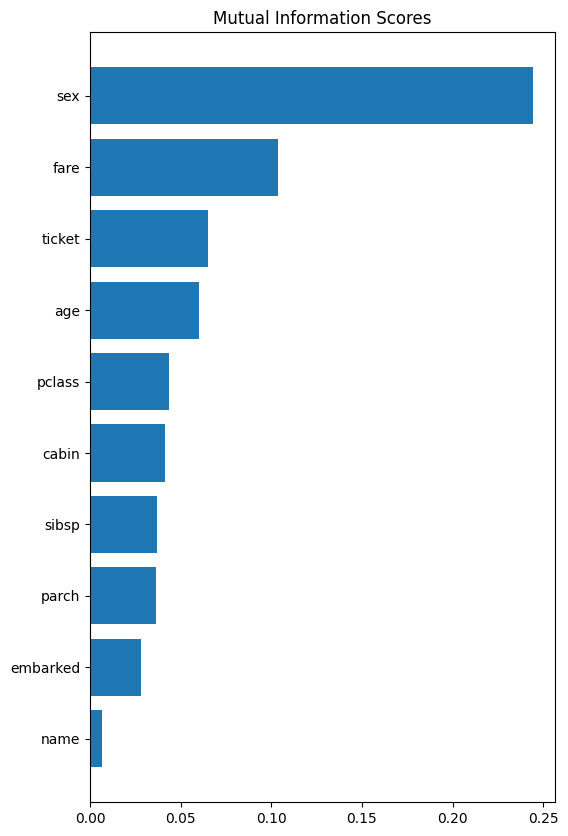

In [706]:
from matplotlib import pyplot as plt

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plt.figure(dpi=100, figsize=(6, 10))
plot_mi_scores(mi_scores)

## 5. Ingeniería de Propiedades 

In [707]:
df_final = df.copy()
properties_final = df_final.copy()
target_final = properties_final.pop('survived')

df_final.columns

Index(['survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked'],
      dtype='object')

In [708]:
import pandas as pd

# Convertir características categóricas en representaciones numéricas basadas en la relación con la variable objetivo (target).

# Extraer la letra de la cabina (cubierta). Expand = False para devolver una Serie
df_final['cabin_letter'] = df_final['cabin'].str.extract(r'([A-Za-z])', expand=False)

# Calcular la probabilidad de supervivencia por letra
letter_survival_probability = df_final.groupby('cabin_letter')['survived'].mean()

# Target Encoding a la característica "Cabin"
df_final['cabin_target_encoded'] = df_final['cabin_letter'].map(letter_survival_probability)

categorical_features = df_final.select_dtypes(include=['object']).columns.tolist()
df_final = pd.get_dummies(df_final, columns=categorical_features)

# Precisión model base 0.87
score, y_pred, y_test, model = get_random_forest_classifier(df_final, target_final)
print(f'Precision modelo final: {score:.2f}')


Precision modelo final: 1.00


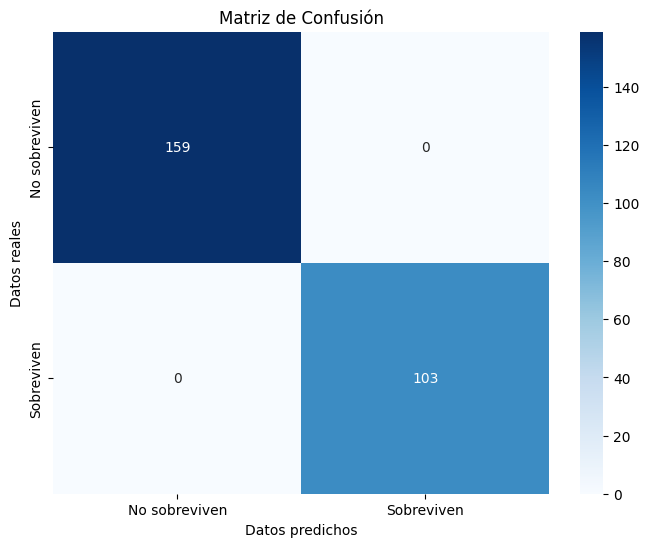

In [713]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_labels=None, figsize=(8, 6)):
    # Calcular la matriz de confusión
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    # Definir etiquetas de clase si no se proporcionan
    if class_labels is None:
        class_labels = ['Class {}'.format(i) for i in range(conf_matrix.shape[0])]
    
    # Crear un heatmap de la matriz de confusión
    plt.figure(figsize=figsize)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    
    # Añadir etiquetas y título
    plt.xlabel('Datos predichos')
    plt.ylabel('Datos reales')
    plt.title('Matriz de Confusión')
    
    # Mostrar el gráfico
    plt.show()


plot_confusion_matrix(y_test, y_pred, class_labels=['No sobreviven', 'Sobreviven'])

## Ingenierías que no cambian la precisión del modelo o la bajan

- Añadir una columna expecificación el género y el status a partir de la información extraida de la columna title donde aparece la forma de tratamiento.

- Crear una característica de "Tamaño de la familia" sumando las características SibSp (número de hermanos/cónyuges a bordo) y Parch (número de padres/hijos a bordo).

-  Crea bandas de edad para transformar la edad en una característica categórica, facilitando la captura de relaciones no lineales con la supervivencia.

In [709]:
# # Añadir una columna expecificación el género y el status a partir de la información extraida de la columna title donde aparece la forma de tratamiento.

# # Extraer el título de la característica 'Name'
# df_final['gender_and_status'] = df_final['name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# # Mapear los títulos según género y clase socioeconómica
# name_mapping = {
#     "Mr": "MaleUpperClass",
#     "Miss": "FemaleMiddleClass",
#     "Mrs": "FemaleUpperClass",
#     "Master": "MaleMiddleClass",
#     "Dr": "MaleUpperClass",  # Considerando que Dr podría ser masculino en este contexto
#     "Rev": "MaleMiddleClass",  # Asumiendo Rev como masculino en este contexto
#     "Major": "MaleUpperClass",
#     "Col": "MaleUpperClass",
#     "Capt": "MaleUpperClass",
#     "Jonkheer": "MaleLowerClass",
#     "Don": "MaleLowerClass",
#     "Sir": "MaleUpperClass",
#     "Lady": "FemaleUpperClass",
#     "Countess": "FemaleUpperClass",
#     "Dona": "FemaleUpperClass",
#     "Mme": "FemaleUpperClass",
#     "Ms": "FemaleMiddleClass",
#     "Mlle": "FemaleMiddleClass"
# }

# df_final['gender_and_status'] = df_final['gender_and_status'].map(name_mapping)

In [710]:
# Crear una característica de "Tamaño de la familia" sumando las características SibSp (número de hermanos/cónyuges a bordo) y Parch (número de padres/hijos a bordo).

#df_final["family_size"] = df_final.sibsp + df_final.parch + 1

In [711]:
##Crea bandas de edad para transformar la edad en una característica categórica, facilitando la captura de relaciones no lineales con la supervivencia.

# # Definir las bandas de edad y etiquetas correspondientes
# age_bins = [0, 20, 80]  # Definir los límites de las bandas de edad
# age_labels = ['child', 'adult']  # Etiquetas para cada banda de edad

# # Crear una nueva columna 'age_band' que represente la banda de edad
# df_final['age_band'] = pd.cut(df_final['age'], bins=age_bins, labels=age_labels, right=False)

# # Aplicar One-Hot Encoding a la columna 'age_band'
# age_band_one_hot = pd.get_dummies(df_final['age_band'], prefix='age_band')

# # Concatenar el DataFrame original 'df_final' con las nuevas columnas generadas por One-Hot Encoding
# df_final = pd.concat([df_final, age_band_one_hot], axis=1)

# # Eliminar las columnas originales 'age' y 'age_band' ya que ahora están codificadas
# df_final.drop(columns=['age', 'age_band'], inplace=True)

# score, y_pred, y_test, model = get_validation_score(df_final)
# score # output: 0.878705